In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [112]:
i_df = pd.read_csv('Downloads/fct_invoice.csv')

In [113]:
c_df = pd.read_json('Downloads/dim_customer.json')

In [162]:
i_df

,invoice_no,customer_id,category,quantity,price,payment_method,invoice_date,shopping_mall,age,age_group
1,I317333,3433,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul,34.0,30-39
2,I127801,644,Clothing,1,300.08,Cash,2021-11-09,Metrocity,46.0,40-49
3,I173702,4900,Shoes,5,3000.85,Credit Card,2021-05-16,Metropol AVM,46.0,40-49
5,I227836,349,Clothing,5,1500.40,Credit Card,2022-05-24,Forum Istanbul,64.0,60-69
8,I293455,3208,Clothing,3,900.24,Credit Card,2021-11-04,Metrocity,35.0,30-39
...,...,...,...,...,...,...,...,...,...,...
99450,I170504,2444,Books,1,15.15,Cash,2023-02-28,Zorlu Center,19.0,10-19
99451,I675411,115,Toys,5,179.20,Cash,2021-10-09,Metropol AVM,36.0,30-39
99452,I219422,2344,Souvenir,5,58.65,Credit Card,2022-09-21,Kanyon,53.0,50-59
99454,I824010,425,Food & Beverage,2,10.46,Debit Card,2021-03-28,Metrocity,36.0,30-39


In [163]:
c_df

,age,first_name,gender,id,last_name,age_decade
0,48.0,Nicholas,M,0,Flores,40.0
1,NaN,Jeffery,M,1,Rowe,NaN
2,57.0,Alexis,F,2,Benton,50.0
3,73.0,Amy,F,3,Johnson,70.0
4,20.0,David,M,4,Moore,20.0
...,...,...,...,...,...,...
5186,NaN,Arthur,M,9428,Harris,NaN
5187,NaN,David,M,9494,Roy,NaN
5188,85.0,Thomas,M,10350,Turner,80.0
5189,NaN,April,F,10587,Sanchez,NaN


Easy
1. How many unique customers are in the dataset?

In [164]:
c_df['id'].nunique()

5191

2. What are the different categories of products available? How many unique categories are there?

In [165]:
i_df['category'].unique()

array(['Shoes', 'Clothing', 'Books', 'Food & Beverage', 'Technology',
       'Cosmetics', 'Souvenir', 'Toys'], dtype=object)

In [166]:
i_df['category'].nunique()

8

3. Which payment method is the most popular? How many times was it used?

In [167]:
i_df.groupby('payment_method').size().head(1)

payment_method
Cash    26671
dtype: int64

In [168]:
i_df['payment_method'].value_counts().head(1)

payment_method
Cash    26671
Name: count, dtype: int64

Medium
1. What are the three most popular categories, by total sales?

In [157]:
i_df.groupby('category')['price'].sum().sort_values(ascending = False).head(3)

category
Clothing      18538642.32
Shoes         10834268.84
Technology     9290400.00
Name: price, dtype: float64

2. What are the total sales attributed to customers over the age of 45?

In [66]:
oldies = c_df[c_df['age'] > 45]['id']
oldies_sales = i_df[i_df['customer_id'].isin(oldies)]
oldies_sales['price'].sum()

22370553.269999996

In [65]:
#one liner
i_df[i_df['customer_id'].isin(c_df[c_df['age'] > 45]['id'])]['price'].sum()

22370553.269999996

3. How is the data distributed across different invoice dates? Are there any seasonal trends or patterns? (Use a graph for this.)

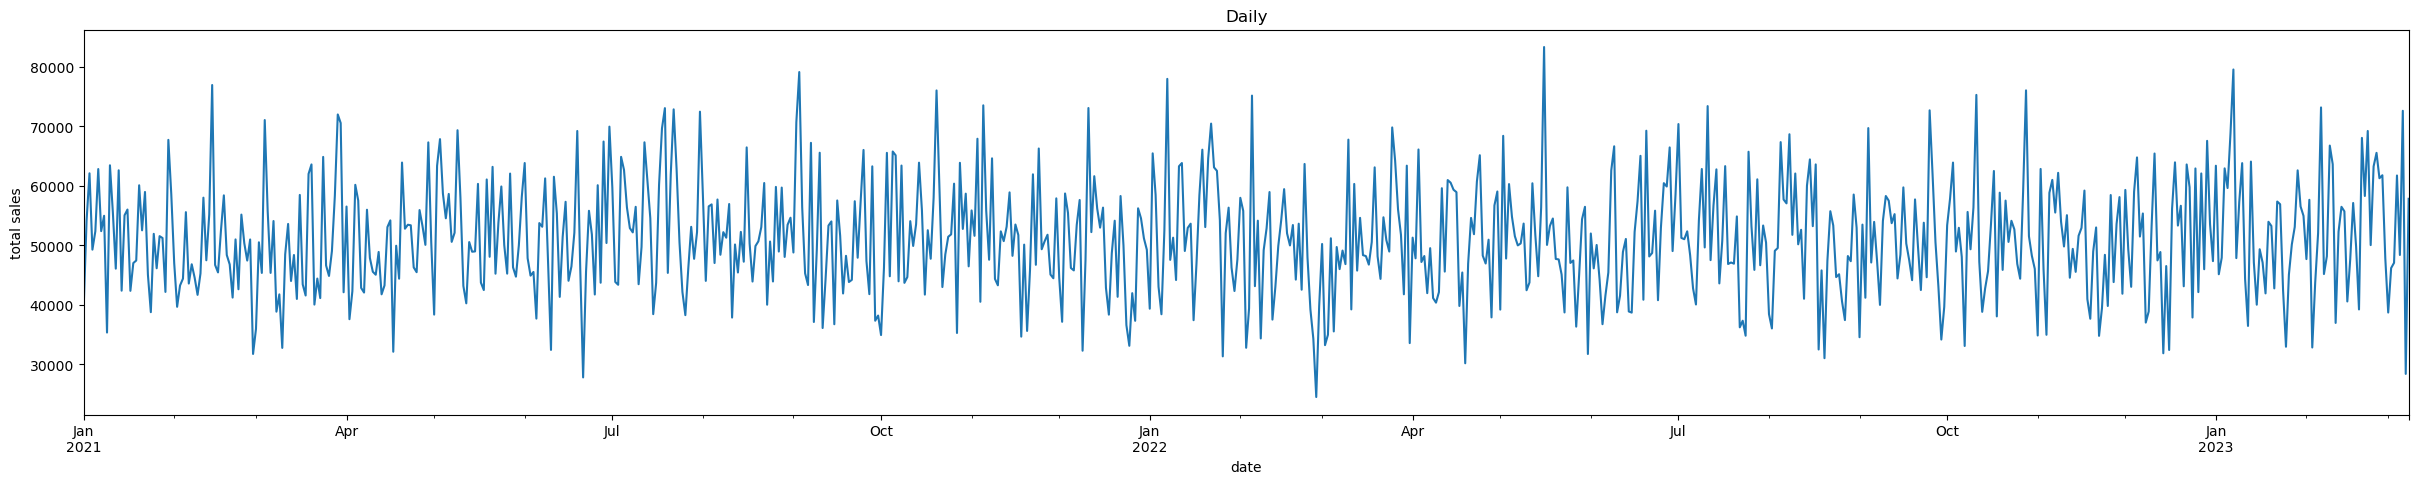

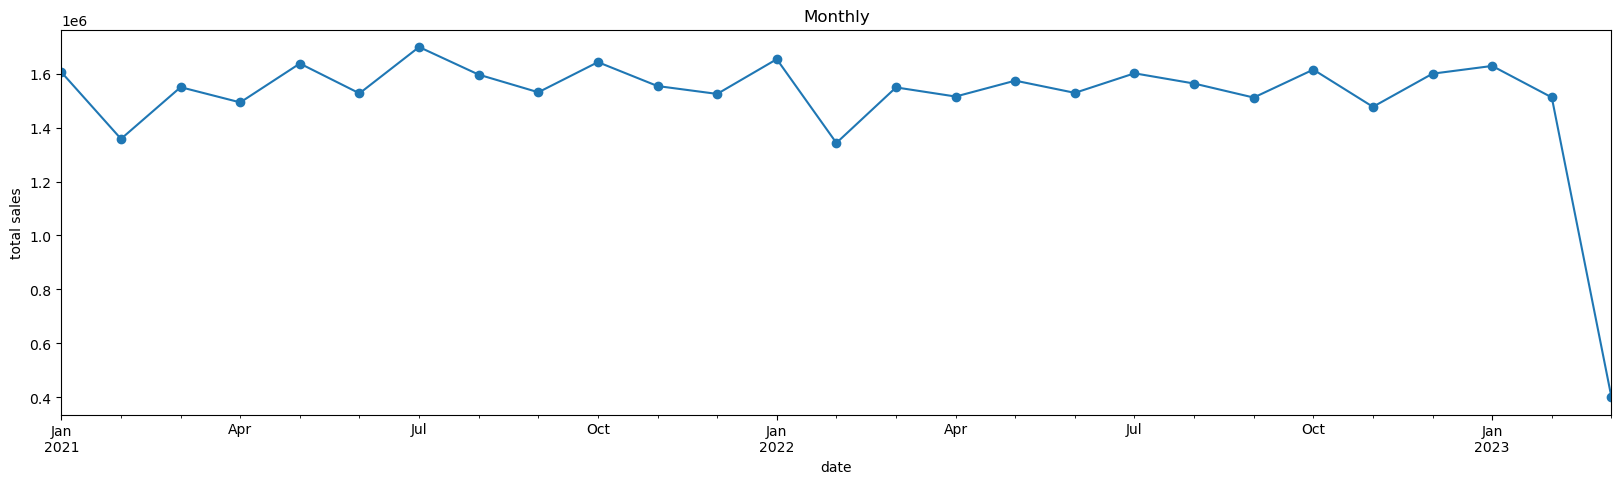

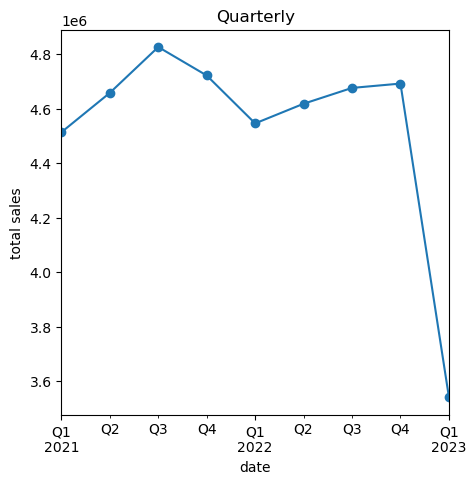

In [153]:
i_df['invoice_date'] = pd.to_datetime(i_df['invoice_date'], dayfirst=True)

daily_sales = i_df.groupby(pd.Grouper(key='invoice_date', freq='D'))['price'].sum()

plt.figure(figsize=(30,5))
daily_sales.plot(kind='line')
plt.title('Daily')
plt.xlabel('date')
plt.ylabel('total sales')
plt.show()

monthly_sales = i_df.groupby(pd.Grouper(key='invoice_date', freq='ME'))['price'].sum()

plt.figure(figsize=(20,5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly')
plt.xlabel('date')
plt.ylabel('total sales')
plt.show()

quarterly_sales = i_df.groupby(pd.Grouper(key='invoice_date', freq='QE'))['price'].sum()

plt.figure(figsize=(5,5))
quarterly_sales.plot(kind='line', marker='o')
plt.title('Quarterly')
plt.xlabel('date')
plt.ylabel('total sales')
plt.show()

Hard
1. Create a pivot table showing the breakdown of sales across these dimensions, in this order: category, decade age range (e.g., 10-19, 20-29, and so forth).

In [146]:
id_to_age = dict(zip(c_df['id'], c_df['age']))
i_df.loc[:, 'age'] = i_df['customer_id'].map(id_to_age)
i_df = i_df.dropna(subset='age')
i_df.loc[:,'age_group'] = i_df['age'].astype(int).apply(lambda x: f"{x // 10 * 10}-{(x // 10 * 10) + 9}")

i_df.pivot_table(
    values='price',
    index='category',
    columns='age_group',
    aggfunc='sum',
    fill_value=0
)

age_group,10-19,20-29,30-39,40-49,50-59,60-69,70-79,80-89
category,,,,,,,,
Books,3469.35,21619.05,22997.70,23361.30,20664.60,21513.00,15437.85,7575.00
Clothing,518238.16,2818351.36,3074919.76,3066817.60,2803647.44,2910776.00,2117064.40,1228827.60
Cosmetics,29681.80,165079.60,198054.86,181343.60,160932.28,176627.04,114132.62,71236.32
Food & Beverage,3645.31,20428.38,23744.20,24460.71,19999.52,22190.89,14968.26,8561.51
Shoes,274277.69,1630061.72,1912141.62,1889335.16,1591650.84,1618058.32,1210542.89,708200.60
Souvenir,3296.13,15295.92,17548.08,17759.22,15084.78,15331.11,10592.19,6545.34
Technology,287700.00,1426950.00,1669500.00,1630650.00,1220100.00,1529850.00,977550.00,548100.00
Toys,17203.20,102466.56,115297.28,106910.72,94115.84,100244.48,74475.52,43043.84
